# Урок 07. Вероятность с нуля

> **Зачем это нужно:** любая ML-модель оценивает вероятности (даже когда вы этого не видите).

# Основы теории вероятностей для ML: Событие и Вероятность

В машинном обучении (ML) мы постоянно работаем с неопределенностью. Например, событием может быть клик пользователя по рекламе, а вероятностью — прогноз нашей модели.

---

## 1. Что такое событие?
**Событие** (обозначается заглавной буквой, например, A) — это подмножество всех возможных исходов эксперимента. 

### Виды событий в ML:
* **Достоверное:** Произойдет со 100% вероятностью. *(Пример: классификатор выдаст какой-нибудь класс из списка).*
* **Невозможное:** Никогда не произойдет. *(Пример: модель предскажет отрицательную стоимость квартиры).*
* **Случайное:** Может произойти, а может и нет. *(Пример: письмо в почте окажется спамом).*

---

## 2. Что такое вероятность?
**Вероятность события A** (обозначается как P(A)) — это числовая мера нашей уверенности в том, что событие произойдет. 

Вероятность всегда лежит в диапазоне от 0 до 1:

$$0 \le P(A) \le 1$$

### Способы расчета вероятности:
1. **Классический подход:** Отношение количества благоприятных исходов к общему числу равновероятных исходов. 
   * *Пример:* Бросок кубика. Вероятность выпадения шестерки: $P(A) = \frac{1}{6}$.
2. **Частотный (эмпирический) подход:** Отношение числа успехов к общему числу попыток в реальном эксперименте. 
   * *Пример:* Из 1000 писем 150 оказались спамом. Частотная вероятность спама: $P(\text{спам}) = \frac{150}{1000} = 0.15$. На этом принципе обучаются многие базовые ML-алгоритмы (например, Наивный Байес).

---

## 3. Важные операции над событиями

* **Сумма событий ($A \cup B$):** Произойдет или A, или B, или оба сразу. 
  * *В ML:* Вероятность того, что пользователь купит или телефон, или чехол к нему.
* **Произведение событий ($A \cap B$ или AB):** События A и B произойдут одновременно. 
  * *В ML:* Пользователь кликнул на товар **и** оформил заказ.


---

# Аксиоматика Колмогорова

Современная теория вероятностей строится на аксиомах, которые в 1933 году сформулировал советский математик Андрей Колмогоров. Он связал теорию вероятностей с теорией меры, что позволило строго обосновать все вычисления, используемые сегодня в Data Science и машинном обучении.

---

## 1. Вероятностное пространство
В основе аксиоматики лежит тройка $(\Omega, \mathcal{F}, P)$, где:
* $\Omega$ (омега) — **пространство элементарных исходов** (множество всех возможных результатов эксперимента).
* $\mathcal{F}$ — **сигма-алгебра событий** (семейство подмножеств $\Omega$, для которых мы можем определить вероятность).
* $P$ — **вероятностная мера** (функция, которая сопоставляет каждому событию число).

---

## 2. Три аксиомы Колмогорова

### Аксиома 1 (Неотрицательность)
Вероятность любого события неотрицательна. Не существует «отрицательной» уверенности в исходе.
$$P(A) \ge 0 \quad \text{для любого } A \in \mathcal{F}$$

### Аксиома 2 (Нормированность)
Вероятность достоверного события (всего пространства исходов $\Omega$) равна единице.
$$P(\Omega) = 1$$

### Аксиома 3 (Счетная аддитивность / Сигма-аддитивность)
Если события $A_1, A_2, A_3, \dots$ попарно несовместны (не могут произойти одновременно, то есть $A_i \cap A_j = \emptyset$ при $i \neq j$), то вероятность их объединения (суммы) равна сумме их вероятностей:
$$P\left(\bigcup_{i=1}^{\infty} A_i\right) = \sum_{i=1}^{\infty} P(A_i)$$

---

## 3. Важные следствия для машинного обучения

Из этих трех простых правил логически выводятся все остальные свойства вероятности:
* **Вероятность противоположного события:** $P(\overline{A}) = 1 - P(A)$. *Используется при подсчете метрик вроде Error Rate = 1 - Accuracy.*
* **Вероятность невозможного события:** $P(\emptyset) = 0$.
* **Ограниченность сверху:** Вероятность любого события не превышает единицу ($P(A) \le 1$). *Поэтому функция активации Sigmoid в нейросетях зажата между 0 и 1, имитируя вероятность.*
* **Формула включений-исключений:** Если события совместны, то $P(A \cup B) = P(A) + P(B) - P(A \cap B)$.


---
# Условная вероятность (Conditional Probability)

В машинном обучении мы редко оцениваем события изолированно. Чаще всего нам нужно узнать вероятность события при условии, что мы *уже знаем* какую-то информацию. Например, какова вероятность, что транзакция мошенническая, если она совершена ночью из новой страны?

---

## 1. Определение и формула

**Условная вероятность $P(A \mid B)$** — это вероятность наступления события $A$ при условии, что событие $B$ уже произошло.

Формула условной вероятности:
$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}, \quad \text{где } P(B) > 0$$

* $P(A \cap B)$ — вероятность того, что произойдут оба события одновременно.
* $P(B)$ — вероятность условия (новое, урезанное пространство исходов).

---

## 2. Интуиция и сужение пространства исходов

Когда мы говорим «при условии $B$», мы мгновенно забываем про все исходы за пределами $B$. Множество $B$ становится нашим новым «вселенным» (новым пространством исходов $\Omega$). Теперь мы ищем долю, которую занимает пересечение $A \cap B$ внутри этого нового множества $B$.

### Теорема умножения вероятностей
Из формулы условной вероятности напрямую следует правило для поиска вероятности совместного наступления двух событий:
$$P(A \cap B) = P(A \mid B) \cdot P(B) = P(B \mid A) \cdot P(A)$$

---

## 3. Независимые события

Два события $A$ и $B$ называются **независимыми**, если наступление одного из них никак не меняет вероятность наступления другого.

Для независимых событий выполняются условия:
1. $P(A \mid B) = P(A)$
2. $P(B \mid A) = P(B)$
3. **Формула умножения:** $P(A \cap B) = P(A) \cdot P(B)$

*В ML:* На предположении о независимости признаков (хоть часто и ложном) строится алгоритм **Наивный Байесовский Классификатор** (Naive Bayes).

---

## 4. Пример из машинного обучения

Представьте, что мы обучаем спам-фильтр. У нас есть база данных писем:
* $B$ — письмо содержит слово **«Кредит»** (условие).
* $A$ — письмо является **Спамом**.

Если $P(\text{Спам} \mid \text{«Кредит»})$ высокая, модель классифицирует такое письмо как нежелательное.


---
---
# Формула полной вероятности и Теорема Байеса

Эти две концепции — фундамент для байесовского машинного обучения, классификации текстов, анализа аномалий и многих вероятностных моделей. Они позволяют обновлять наши прогнозы при получении новых данных.

---

## 1. Формула полной вероятности

Часто нам сложно рассчитать вероятность события $A$ напрямую, но мы можем сделать это через систему гипотез.

Пусть пространство исходов разбито на систему попарно несовместных гипотез $H_1, H_2, \dots, H_n$ (то есть они не пересекаются и в сумме дают всё пространство $\Omega$: $\sum P(H_i) = 1$). 

Тогда **формула полной вероятности** для любого события $A$ выглядит так:
$$P(A) = \sum_{i=1}^{n} P(A \mid H_i) \cdot P(H_i)$$

*Интуиция:* Мы взвешиваем условную вероятность события $A$ при каждой гипотезе на вероятность самой этой гипотезы.

---

## 2. Теорема Байеса (Bayes' Theorem)

Теорема Байеса позволяет «развернуть» условную вероятность и ответить на вопрос: *«Если событие $A$ уже произошло, какова вероятность, что это случилось из-за гипотезы $H_k$?»*

$$\text{P}(H_k \mid A) = \frac{P(A \mid H_k) \cdot P(H_k)}{P(A)}$$

Если расписать знаменатель $P(A)$ через формулу полной вероятности, получим:
$$P(H_k \mid A) = \frac{P(A \mid H_k) \cdot P(H_k)}{\sum_{i=1}^{n} P(A \mid H_i) \cdot P(H_i)}$$

### Терминология в Machine Learning:
* $P(H_k)$ — **Априорная вероятность** (Prior): наша уверенность в гипотезе *до* того, как мы увидели новые данные $A$.
* $P(A \mid H_k)$ — **Правдоподобие** (Likelihood): насколько вероятно увидеть данные $A$, если гипотеза $H_k$ верна.
* $P(H_k \mid A)$ — **Апостериорная вероятность** (Posterior): обновленная вероятность гипотезы *после* анализа новых данных $A$.
* $P(A)$ — **Нормировочная константа** (Evidence): полная вероятность получить такие данные.

---

## 3. Пример применения в ML (Медицинская диагностика)

Представьте, что модель классифицирует редкую болезнь:
* Болезнь ($H_1$) встречается у **1%** населения: $P(H_1) = 0.01$. Значит, здоровых ($H_2$) — **99%**: $P(H_2) = 0.99$.
* Точность теста (правдоподобие):
  * Если человек болен, тест положителен ($A$) в **95%** случаев: $P(A \mid H_1) = 0.95$.
  * Если человек здоров, тест ошибочно положителен в **5%** случаев: $P(A \mid H_2) = 0.05$.

**Задача:** Тест у пациента оказался положительным ($A$). Какова реальная вероятность, что он болен?

1. Находим полную вероятность положительного теста $P(A)$:
$$P(A) = P(A \mid H_1)P(H_1) + P(A \mid H_2)P(H_2) = 0.95 \cdot 0.01 + 0.05 \cdot 0.99 = 0.0095 + 0.0495 = 0.059$$

2. Считаем апостериорную вероятность по теореме Байеса:
$$P(H_1 \mid A) = \frac{0.95 \cdot 0.01}{0.059} = \frac{0.0095}{0.059} \approx 0.161 \ (16.1\%)$$

*Вывод для ML:* Из-за низкой априорной вероятности болезни ($1\%$), даже при точной модели ($95\%$), большинство положительных срабатываний будут ложными. Модели нужно обучаться на сбалансированных данных или учитывать этот перекос.


---
# Глубокое погружение: Интуиция формулы полной вероятности

Формула полной вероятности часто кажется сложной из-за знака суммы $\sum$ и обилия индексов. На самом деле за ней скрывается очень простая и жизненная логика: **«разделяй и властвуй»**. 

---

## 1. Интуитивная аналогия: Фабрика и Смартфоны

Представьте, что вы владелец бренда смартфонов. Ваши телефоны собираются на **трех разных заводах** (это наши гипотезы $H_1, H_2, H_3$):
* **Завод 1 ($H_1$)** производит **50%** всех телефонов.
* **Завод 2 ($H_2$)** производит **30%** всех телефонов.
* **Завод 3 ($H_3$)** производит **20%** всех телефонов.

Вы знаете, что идеальных заводов не бывает, и на каждом есть свой процент брака (событие $A$ — телефон бракованный):
* На **Заводе 1** брак составляет **1%** (условная вероятность $P(A \mid H_1) = 0.01$).
* На **Заводе 2** брак составляет **2%** (условная вероятность $P(A \mid H_2) = 0.02$).
* На **Заводе 3** брак составляет **5%** (условная вероятность $P(A \mid H_3) = 0.05$).

**Вопрос:** Какова общая вероятность того, что случайно купленный в магазине телефон вашего бренда окажется бракованным ($P(A)$)?

Вы не можете просто сложить проценты брака ($1\% + 2\% + 5\% = 8\%$) или взять среднее ($2.67\%$), потому что заводы производят **разное количество** телефонов. Логично, что вклад Завода 1 в общую кучу брака должен быть больше, так как он делает половину всех смартфонов.

---

## 2. Как рассуждать математически?

Чтобы найти весь брак, нам нужно сложить бракованные телефоны с каждого завода в отдельности:
$$\text{Весь брак} = (\text{Брак с 1-го завода}) + (\text{Брак со 2-го завода}) + (\text{Брак с 3-го завода})$$

Как найти брак с конкретного завода? 
Нужно умножить *долю этого завода в общем объеме* на *процент брака на этом заводе*:
* Брак с 1-го завода = $P(H_1) \cdot P(A \mid H_1) = 0.50 \cdot 0.01 = 0.005$ (или 0.5% от всей массы телефонов).
* Брак со 2-го завода = $P(H_2) \cdot P(A \mid H_2) = 0.30 \cdot 0.02 = 0.006$ (или 0.6% от всей массы телефонов).
* Брак с 3-го завода = $P(H_3) \cdot P(A \mid H_3) = 0.20 \cdot 0.05 = 0.010$ (или 1.0% от всей массы телефонов).

Теперь складываем эти кусочки:
$$P(A) = 0.005 + 0.006 + 0.010 = 0.021 \quad (2.1\%)$$

---

## 3. Геометрическая визуализация (Взгляд через площади)

Представьте прямоугольник — это вся ваша компания ($\Omega$), его общая площадь равна **1**.
1. Мы делим этот прямоугольник вертикальными линиями на 3 части (заводы $H_1, H_2, H_3$). Площадь каждой части — это доля производства ($0.5, 0.3, 0.2$). Они не пересекаются и вместе занимают весь прямоугольник.
2. Теперь внутри каждого завода мы заштриховываем маленькие кусочки — это брак ($A$). 
   * Внутри $H_1$ заштриховано $1\%$, внутри $H_2$ — $2\%$, внутри $H_3$ — $5\%$.
3. Общая вероятность $P(A)$ — это **суммарная площадь всех заштрихованных кусочков**.

---

## 4. Строгая формула

Смысл формулы — это в точности то, что мы проделали со смартфонами. Мы разбиваем сложное событие $A$ на понятные кусочки, считаем площадь каждого кусочка через условную вероятность и складываем их:

$$P(A) = P(A \mid H_1)P(H_1) + P(A \mid H_2)P(H_2) + \dots + P(A \mid H_n)P(H_n)$$

Или в свернутом виде через знак суммы:
$$P(A) = \sum_{i=1}^{n} P(A \mid H_i) \cdot P(H_i)$$

### Главные условия, чтобы формулу можно было применять:
1. **Гипотезы не пересекаются** ($H_i \cap H_j = \emptyset$). Телефон не может быть собран одновременно на Заводе 1 и Заводе 2.
2. **Гипотезы покрывают всё пространство** ($\sum P(H_i) = 1$). Телефон обязательно собран на одном из этих заводов, четвертого не дано.


---
---

## 4. Формула Байеса — главное уравнение ML

$$ P(\theta | D) = \frac{P(D | \theta) \cdot P(\theta)}{P(D)} $$

Где:
- `P(θ | D)` — апостериорное (что мы хотим узнать).
- `P(D | θ)` — правдоподобие (модель).
- `P(θ)` — априорное (что знали до).
- `P(D)` — нормирующая константа.

**Пример:** тест на болезнь, точность 99%. Заболеваемость в популяции 0.1%. Тест положительный. Какова вероятность, что человек болен?

Этот классический пример иллюстрирует базовый парадокс теоремы Байеса: даже при очень точном тесте вероятность быть больным после положительного результата остается низкой, если сама болезнь встречается крайне редко.

In [1]:
P_disease = 0.001
P_healthy = 1 - P_disease
P_pos_given_disease = 0.99
P_pos_given_healthy = 0.01

# Вероятность того, что тест положительный
P_pos = P_pos_given_disease * P_disease + P_pos_given_healthy * P_healthy

# Вероятность того, что человек болен, когда тест положительный
P = (P_pos_given_disease * P_disease) / P_pos
print(P)
print(round((100 * P), 2), "%")

0.09016393442622951
9.02 %


---
# Случайные величины (Random Variables)

В машинном обучении алгоритмы не могут работать напрямую с абстрактными исходами вроде «письмо — спам» или «клиент ушел». **Случайная величина** выступает в роли «переводчика»: она отображает пространство элементарных исходов в вещественные числа.

---

## 1. Строгое математическое определение

Пусть задано вероятностное пространство $(\Omega, \mathcal{F}, P)$. 
**Случайная величина** $X$ — это измеримая функция, отображающая пространство элементарных исходов $\Omega$ в множество вещественных чисел $\mathbb{R}$:

$$X: \Omega \rightarrow \mathbb{R}$$

Свойство измеримости означает, что для любого вещественного числа $x$ подмножество исходов $\{\omega \in \Omega \mid X(\omega) \le x\}$ является событием, принадлежащим сигма-алгебре $\mathcal{F}$, а значит, мы можем посчитать его вероятность.

Все случайные величины разделяются на два основных типа: **дискретные** и **непрерывные**.

---

## 2. Дискретные случайные величины (ДСВ)

Случайная величина называется **дискретной**, если множество её возможных значений конечно или счетно (их можно пересчитать: $x_1, x_2, \dots, x_n, \dots$).

### Закон распределения ДСВ
Задается в виде таблицы, где каждому значению $x_i$ сопоставлена его вероятность $p_i = P(X = x_i)$:

| $X$ | $x_1$ | $x_2$ | $\dots$ | $x_n$ |
| :--- | :--- | :--- | :--- | :--- |
| $P$ | $p_1$ | $p_2$ | $\dots$ | $p_n$ |

**Условие нормировки:** Сумма вероятностей всех возможных исходов обязана быть равной единице:
$$\sum_{i} p_i = 1$$

*Применение в ML:* Таргет в задачах бинарной классификации (0 или 1), количество кликов на баннер, число купленных товаров.

---

## 3. Непрерывные случайные величины (НСВ)

Случайная величина называется **непрерывной**, если её функция распределения непрерывна, а множество значений заполняет некоторый интервал (конечный или бесконечный).

Вероятность того, что НСВ примет *точное* конкретное значение $x_0$, всегда равна нулю: $P(X = x_0) = 0$. Поэтому для них оценивают вероятность попадания в интервал.

### Функция плотности распределения (Probability Density Function — PDF)
Для описания НСВ используется функция плотности $f(x)$. Она показывает, насколько «кучно» распределены вероятности около точки $x$.

Вероятность попадания случайной величины в интервал $[a, b]$ равна интегралу от плотности:
$$P(a \le X \le b) = \int_{a}^{b} f(x) \, dx$$

**Свойства плотности $f(x)$:**
1. Неотрицательность: $f(x) \ge 0$
2. **Условие нормировки** (площадь под всем графиком равна 1): 
$$\int_{-\infty}^{+\infty} f(x) \, dx = 1$$

*Применение в ML:* Прогноз стоимости недвижимости в регрессии, время сессии пользователя на сайте, веса в нейронных сетях.

---

## 4. Универсальный инструмент: Функция распределения (CDF)

**Функция распределения** (Cumulative Distribution Function) существует для *любого* типа случайных величин. Она показывает вероятность того, что случайная величина $X$ примет значение, строго меньшее $x$:

$$F(x) = P(X < x)$$

* **Для дискретных величин** CDF имеет ступенчатый вид: $F(x) = \sum_{x_i < x} P(X = x_i)$
* **Для непрерывных величин** CDF — это гладкая функция, связанная с плотностью: $F(x) = \int_{-\infty}^{x} f(t) \, dt$, при этом $f(x) = F'(x)$.


---
---
---
# Числовые характеристики случайных величин

Чтобы эффективно работать со случайными величинами в машинном обучении, нам нужно уметь описывать их поведение несколькими числами. Две главные характеристики любого распределения — это **математическое ожидание** (центр распределения) и **дисперсия** (разброс вокруг этого центра).

---

## 1. Математическое ожидание (Expected Value)

**Математическое ожидание $E[X]$ (или $M[X]$)** — это средневзвешенное значение случайной величины, где в качестве весов выступают вероятности этих значений. В ML это аналог среднего значения по генеральной совокупности.

### Математическое определение:
* **Для дискретных случайных величин (ДСВ):**
$$E[X] = \sum_{i} x_i p_i$$

* **Для непрерывных случайных величин (НСВ):**
$$E[X] = \int_{-\infty}^{+\infty} x f(x) \, dx$$

*(Здесь и далее предполагается, что ряд абсолютно сходится, а интеграл существует).*

### Важные свойства математического ожидания:
1. **Линейность:** $E[aX + bY] = aE[X] + bE[Y]$ (выполняется для *любых* случайных величин, даже зависимых). 
2. Матожидание константы — сама константа: $E[C] = C$.
3. Для *независимых* величин матожидание произведения равно произведению матожиданий: $E[X \cdot Y] = E[X] \cdot E[Y]$.

*Применение в ML:* Лежит в основе расчета функции потерь MSE (Mean Squared Error), где мы минимизируем средний квадрат ошибки.

---

## 2. Дисперсия (Variance)

**Дисперсия $Var(X)$ (или $D[X]$)** — это математическое ожидание квадрата отклонения случайной величины от её математического ожидания. Она измеряет степень разброса значений вокруг центра.

### Математическое определение:
$$Var(X) = E\left[(X - E[X])^2\right]$$

**Расчетная формула** (её гораздо удобнее использовать на практике):
$$Var(X) = E[X^2] - (E[X])^2$$

* **Для ДСВ:** $Var(X) = \sum_{i} (x_i - E[X])^2 p_i$
* **Для НСВ:** $Var(X) = \int_{-\infty}^{+\infty} (x - E[X])^2 f(x) \, dx$

### Важные свойства дисперсии:
1. Дисперсия всегда неотрицательна: $Var(X) \ge 0$.
2. Дисперсия константы равна нулю: $Var(C) = 0$.
3. Вынос константы за знак дисперсии: $Var(cX) = c^2 Var(X)$ (константа выносится в квадрате).
4. Для *независимых* случайных величин дисперсия суммы равна сумме дисперсий: $Var(X + Y) = Var(X) + Var(Y)$.

---

## 3. Среднеквадратическое отклонение (Standard Deviation)

Дисперсия измеряется в «квадратных единицах» (например, если $X$ — цена в рублях, то дисперсия — в рублях в квадрате). Чтобы вернуть размерность к исходной, используют **среднеквадратическое отклонение $\sigma$ (сигма)**:

$$\sigma = \sqrt{Var(X)}$$

---

## 4. Зачем это нужно в Machine Learning?

1. **Нормализация данных (StandardScaler):** При подготовке данных к обучению (особенно для линейных моделей и нейросетей) признаки масштабируют по формуле:
$$X_{new} = \frac{X - E[X]}{\sigma}$$
После этого среднее значение признака становится равным 0, а дисперсия — 1. Это защищает модель от перекосов, если один признак измеряется в миллионах, а другой — в долях единицы.

2. **Оценка стабильности:** Низкая дисперсия ошибок модели говорит о её стабильности. Высокая дисперсия указывает на переобучение (Overfitting), когда модель слишком чувствительна к шумам в данных.


In [2]:
import numpy as np

# loc - математическое ожидание равно 5
# scale - среднеквадратичное отклонение равно 2
np.random.seed(42)
X = np.random.normal(loc=5, scale=2, size=1000)
print(f"Математическое ожидание равно E(X) = {X.mean()}")
print(f"Дисперсия равна D(X) = Var(X) = {X.var()}")
print(f"Среднеквадратичное отклонение равно (X) = {X.std()}")


Математическое ожидание равно E(X) = 5.0386641116446516
Дисперсия равна D(X) = Var(X) = 3.831619958926069
Среднеквадратичное отклонение равно (X) = 1.9574524154947086


---
---
# Основные распределения случайных величин в ML

В машинном обучении и статистике реальные данные часто подчиняются стандартным законам распределения. Знание этих законов помогает правильно выбирать функции потерь, инициализировать веса нейросетей и строить вероятностные модели.

---

## 1. Дискретные распределения

### Распределение Бернулли (Bernoulli Distribution)
Описывает эксперимент с двумя исходами: «успех» ($X=1$) с вероятностью $p$ или «неудача» ($X=0$) с вероятностью $1-p$.
* **Матожидание:** $E[X] = p$
* **Дисперсия:** $Var(X) = p(1-p)$
* *Применение в ML:* Моделирование бинарной классификации (кликнет ли пользователь по рекламе, уйдет ли клиент из банка). На нем основана функция потерь *Binary Cross-Entropy*.

### Биномиальное распределение (Binomial Distribution)
Описывает число «успехов» в серии из $n$ независимых испытаний Бернулли. Вероятность получить ровно $k$ успехов:
$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$
* **Матожидание:** $E[X] = np$
* **Дисперсия:** $Var(X) = np(1-p)$
* *Применение в ML:* Оценка конверсии, A/B-тестирование (например, сколько пользователей из группы в 1000 человек совершат покупку).

---

## 2. Непрерывные распределения

### Нормальное распределение / Распределение Гаусса (Normal Distribution)
Самое важное распределение в Data Science. Задается двумя параметрами: матожиданием $\mu$ (центр) и среднеквадратическим отклонением $\sigma$ (разброс). Обозначается как $\mathcal{N}(\mu, \sigma^2)$.

Плотность вероятности имеет форму колокола:
$$f(x) = \frac{1}{\sigma \sqrt{2\pi}} \exp\left( -\frac{(x - \mu)^2}{2\sigma^2} \right)$$

* **Матожидание:** $E[X] = \mu$
* **Дисперсия:** $Var(X) = \sigma^2$
* **Правило трех сигм ($3\sigma$):** 68.2% всех значений лежат в пределах $[\mu \pm \sigma]$, 95.4% — в пределах $[\mu \pm 2\sigma]$, и 99.7% — в пределах $[\mu \pm 3\sigma]$.
* *Применение в ML:* 
  1. Ошибки большинства регрессионных моделей предполагаются распределенными нормально.
  2. Начальная инициализация весов в нейросетях часто делается из нормального распределения.
  3. Поиск аномалий (все, что вылетает за рамки $3\sigma$, считается выбросом).

### Равномерное распределение (Uniform Distribution)
Плотность вероятности постоянна на некотором интервале $[a, b]$ и равна нулю вне его. Все исходы внутри интервала равновероятны.
$$f(x) = \frac{1}{b - a} \quad \text{для } x \in [a, b]$$
* **Матожидание:** $E[X] = \frac{a + b}{2}$
* **Дисперсия:** $Var(X) = \frac{(b - a)^2}{12}$
* *Применение в ML:* Инициализация весов (методы Xavier или He равномерно распределяют начальные веса), генерация случайных чисел для аугментации данных.


---
---
# Совместные распределения и взаимосвязь признаков

В реальных датасетах мы работаем не с одной изолированной переменной, а с целыми матрицами признаков (например, предсказание стоимости квартиры по её площади, району и этажу одновременно). Нам необходимо математически описывать их совместное поведение.

---

## 1. Совместное распределение (Joint Distribution)

Пусть у нас есть две случайные величины $X$ и $Y$. Их **совместная функция распределения** определяет вероятность того, что $X$ примет значение меньше $x$, а $Y$ одновременно с этим — значение меньше $y$:

$$F(x, y) = P(X < x, Y < y)$$

* **Для дискретных величин:** задается таблицей совместных вероятностей $P(X = x_i, Y = y_j)$.
* **Для непрерывных величин:** описывается двумерной плотностью вероятности $f(x, y)$, где вероятность попадания в область — это объем под графиком плотности (двойной интеграл).

### Независимость случайных величин
Случайные величины $X$ и $Y$ независимы, если их совместная плотность (или вероятность) распадается на произведение одномерных (маргинальных) плотностей:
$$f(x, y) = f_X(x) \cdot f_Y(y)$$

---

## 2. Ковариация (Covariance)

**Ковариация $Cov(X, Y)$** — это мера линейной зависимости двух случайных величин. Она показывает, изменяются ли две величины в одном направлении или в противоположных.

### Математическое определение:
$$Cov(X, Y) = E\left[(X - E[X])(Y - E[Y])\right]$$

**Расчетная формула:**
$$Cov(X, Y) = E[X Y] - E[X]E[Y]$$

### Интерпретация знака ковариации:
* $Cov(X, Y) > 0$: Переменные растут одновременно (например, площадь квартиры и её цена).
* $Cov(X, Y) < 0$: При росте одной переменной другая убывает (например, возраст автомобиля и его цена).
* $Cov(X, Y) = 0$: Линейная взаимосвязь отсутствует. 

*Важно:* Если величины независимы, их ковариация строго равна 0. Но обратное **не всегда верно**: ковариация может быть равна 0 при наличии сильной нелинейной зависимости (например, параболической).

---

## 3. Корреляция Пирсона (Correlation)

Главный минус ковариации — она зависит от масштаба и единиц измерения. Если измерять рост в метрах, ковариация будет одной, а если в миллиметрах — в миллион раз больше.

Чтобы избавиться от масштаба, ковариацию нормируют на среднеквадратические отклонения обеих величин. Так получается **коэффициент корреляции Пирсона $\rho$**:

$$\rho_{X,Y} = \frac{Cov(X, Y)}{\sigma_X \cdot \sigma_Y}$$

### Свойства корреляции:
1. **Строгие границы:** $-1 \le \rho \le 1$.
2. $\rho = 1$: Идеальная прямая линейная зависимость.
3. $\rho = -1$: Идеальная обратная линейная зависимость.
4. $\rho = 0$: Линейной связи нет (величины называют *некоррелированными*).

---

## 4. Применение в Machine Learning

1. **Матрица ковариации (Covariance Matrix):** Для многомерных данных (много признаков) считается матрица, где на пересечении $i$-й строки и $j$-го столбца стоит ковариация между ними. На основе этой матрицы работает **Метод главных компонент (PCA)** для снижения размерности данных.
2. **Мультиколлинеарность:** Если корреляция между двумя входными признаками близка к $1$ или $-1$, это вредит линейным моделям (коэффициенты становятся нестабильными). На этапе разведочного анализа данных (EDA) такие фичи часто находят через тепловую карту (`sns.heatmap(df.corr())`) и одну из них удаляют.


---
---
---
# ⚠️ Главное правило Data Science: Корреляция ≠ Причинность

Эта фраза (на английском: *Correlation is not causation*) — самый частый триггер на собеседованиях по анализу данных и Machine Learning. Ошибки в понимании этого принципа стоят бизнесу миллионов рублей.

---

## В чем разница?

*   **Корреляция (Взаимосвязь)**: Два показателя меняются синхронно. Если растет $A$, то растет (или падает) $B$. Это чистая математика и статистика.
*   **Причинно-следственная связь (Каузальность)**: Изменение показателя $A$ является *прямой причиной* изменения показателя $B$.

---

## Почему статистика видит связь там, где её нет?

Выделяют три основные математические и логические ловушки:

### 1. Скрытый третий фактор (Confounding Variable)
Показатели $A$ и $B$ растут вместе только потому, что на оба влияет скрытый фактор $C$.
*   **Пример**: Летом продажи мороженого ($A$) сильно коррелируют с количеством несчастных случаев на воде ($B$).
*   **Ложная логика**: Запретить мороженое, чтобы спасти людей.
*   **Реальность**: Скрытый фактор $C$ — жара. Она заставляет людей и покупать мороженое, и идти купаться.

### 2. Обратная причинность (Reverse Causality)
Связь реальна, но аналитик путает причину и следствие местами.
*   **Пример**: В больницах с самым дорогим и продвинутым оборудованием ($A$) фиксируется самый высокий уровень смертности пациентов ($B$).
*   **Ложная логика**: Оборудование портит здоровье, нужно его убрать.
*   **Реальность**: Всё ровно наоборот. В клиники с лучшим оборудованием везут самых тяжелых пациентов, которых нельзя спасти в обычных больницах.

### 3. Случайное совпадение (Spurious Correlation)
Если проанализировать тысячи случайных графиков, чисто математически некоторые из них идеально совпадут без какой-либо логики.
*   **Пример**: График потребления сыра в стране идеально повторяет кривую числа людей, запутавшихся в постельном белье. Это просто статистический шум.

---

## Зачем это спрашивают на собеседованиях?

1.  **Защита от «глупых» признаков в ML**: Модель может найти случайную корреляцию в исторических данных. Если этот паттерн сломается на проде, модель начнет жестко ошибаться на реальных пользователях.
2.  **Корректная проверка продуктовых гипотез**: Если пользователи, заходящие в раздел «Помощь», чаще уходят из приложения, это не значит, что раздел плохой. У людей *уже* что-то сломалось, удаление раздела не решит проблему.
3.  **Понимание А/В-тестирования**: Единственный строгий способ доказать каузальность в Data Science — это контролируемый **A/B-тест**, который изолирует все внешние факторы.


---

## 8. Практические задания

1. **Болезнь и тест.** Постройте таблицу: для заболеваемости 0.01%, 1%, 10% и точности теста 90%, 99%, 99.9% — какова апостериорная вероятность болезни при положительном тесте?


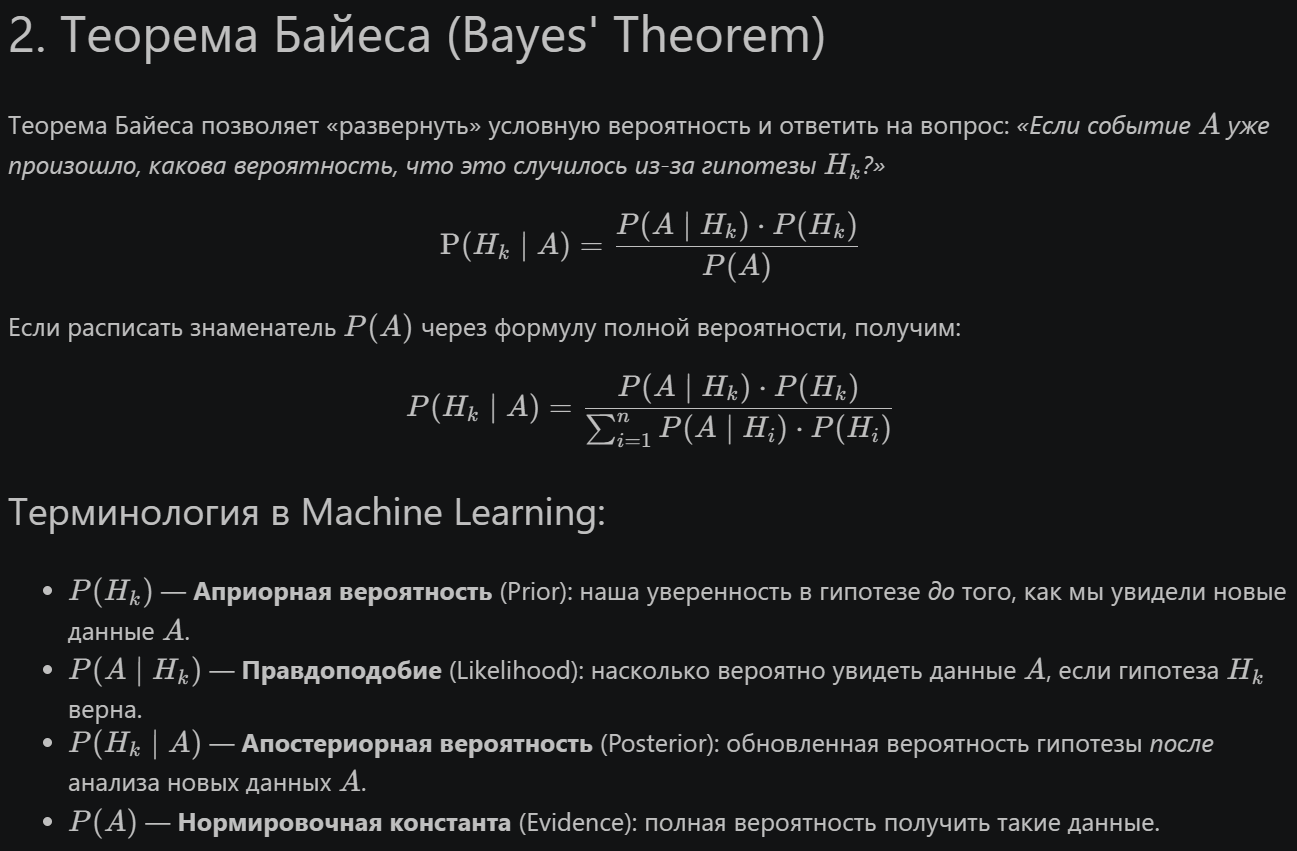

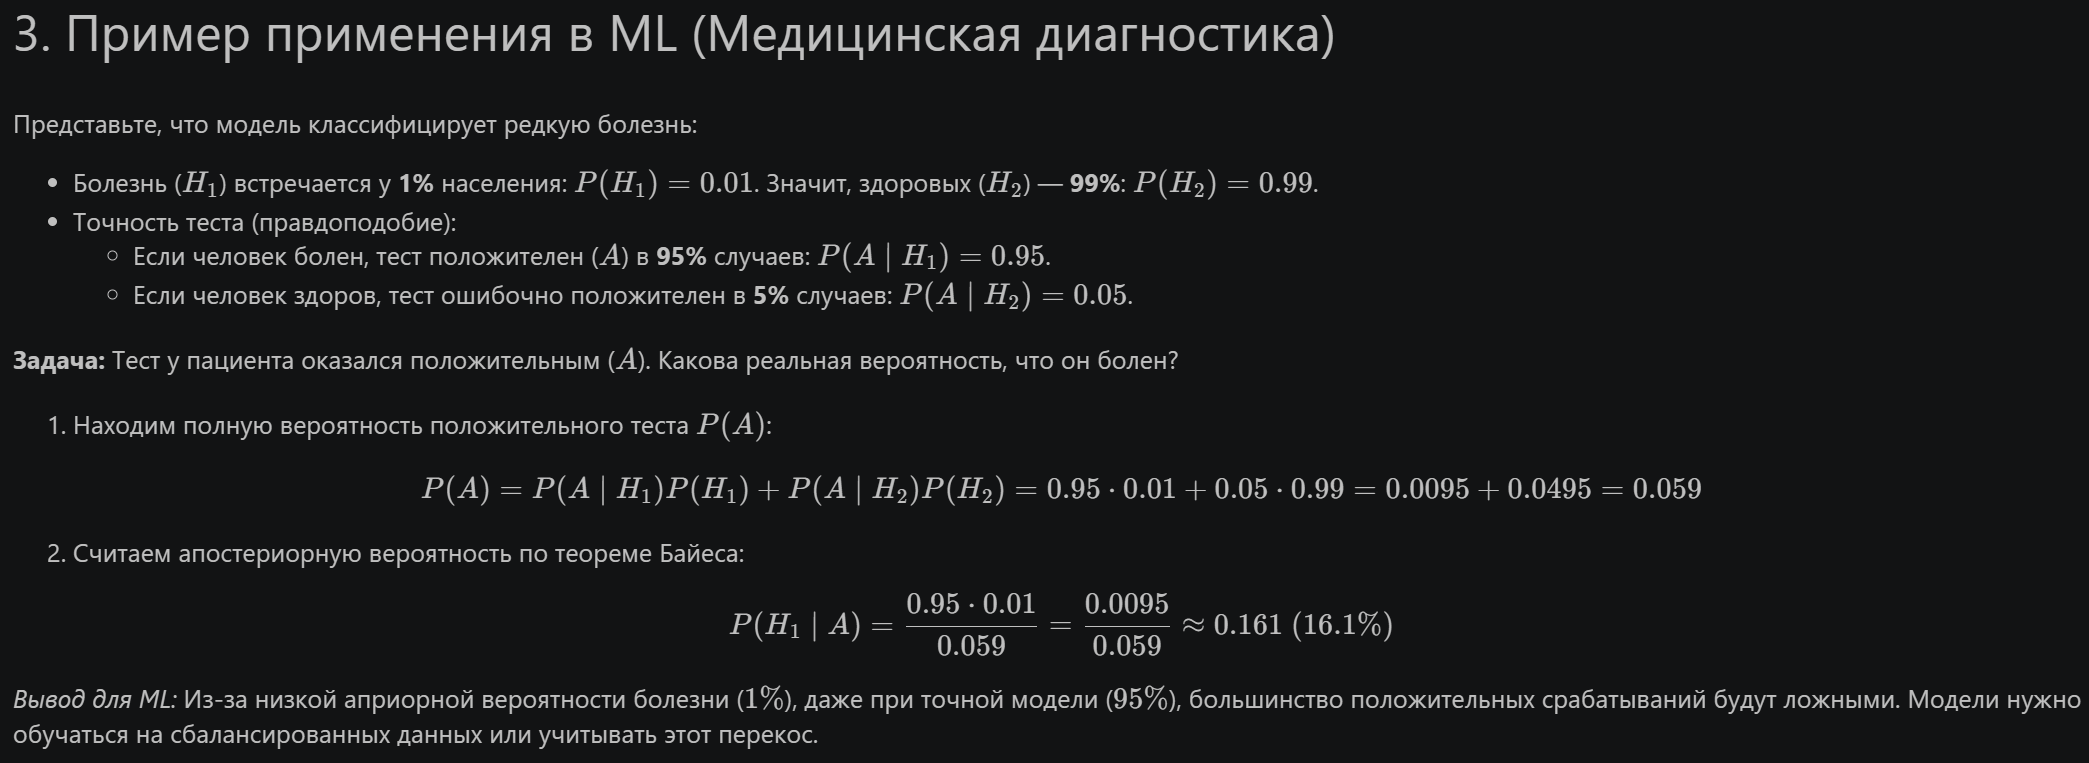

In [3]:
P_disease_val = [0.0001, 0.01, 0.1]
P_pos_given_disease_val = [0.9, 0.99, 0.999]
k = 1
for P_disease in P_disease_val:
    print(f"Заболеваемость: {P_disease}")
    for P_pos_given_disease in P_pos_given_disease_val:
        k+=1
        P_healthy = 1 - P_disease
        P_pos_given_healthy = 1 - P_pos_given_disease

        P_pos = P_pos_given_healthy * P_healthy + P_disease * P_pos_given_disease
        P_posterior = P_disease * P_pos_given_disease / P_pos

        # вероятность того, что человек болен, если тест был положительным
        print(f"Точность теста: {P_pos_given_disease} -> апостериорная вероятность: {P_posterior:.3f}")
    print()

Заболеваемость: 0.0001
Точность теста: 0.9 -> апостериорная вероятность: 0.001
Точность теста: 0.99 -> апостериорная вероятность: 0.010
Точность теста: 0.999 -> апостериорная вероятность: 0.091

Заболеваемость: 0.01
Точность теста: 0.9 -> апостериорная вероятность: 0.083
Точность теста: 0.99 -> апостериорная вероятность: 0.500
Точность теста: 0.999 -> апостериорная вероятность: 0.910

Заболеваемость: 0.1
Точность теста: 0.9 -> апостериорная вероятность: 0.500
Точность теста: 0.99 -> апостериорная вероятность: 0.917
Точность теста: 0.999 -> апостериорная вероятность: 0.991



---
2. **Парадокс Монти Холла.** Симулируйте 100 000 игр. Сравните стратегии «не менять» и «менять». Какая выигрывает чаще?


In [4]:
n_games = 100000
victory = {"change" : 0, "not_change" : 0}

for i in range(n_games):
    doors = {1, 2, 3}  # Используем множество для удобного вычитания
    door_car = np.random.choice(list(doors))
    door_player = np.random.choice(list(doors))
    possible_leader_doors = list(doors - {door_player, door_car})
    door_leader = np.random.choice(possible_leader_doors)

    # меняем выбор игрок 
    door_for_change = list(doors - {door_player, door_leader})[0]
    if door_for_change == door_car:
        victory["change"] += 1

    # не меняем выбор игрок
    if door_player == door_car:
        victory["not_change"] += 1
        
print(victory)




{'change': 66505, 'not_change': 33495}


--- 
## Математическое доказательство

Решим задачу строго через теорию вероятностей, используя **формулу полной вероятности** и **теорему Байеса**.

### 1. Формализация задачи
Пусть за одной из трех дверей спрятан автомобиль. Обозначим априорные гипотезы о том, где находится машина:
* $H_1$: Машина за дверью №1
* $H_2$: Машина за дверью №2
* $H_3$: Машина за дверью №3

Так как машина размещается случайно, начальные вероятности гипотез равны:
$$P(H_1) = P(H_2) = P(H_3) = \frac{1}{3}$$

Предположим, **игрок выбрал дверь №1**.
Затем ведущий открывает одну из оставшихся дверей с козой — например, **дверь №3**. Обозначим это как событие $B_3$ — «ведущий открыл дверь №3».

Наша цель — рассчитать апостериорные вероятности $P(H_1 \mid B_3)$ и $P(H_2 \mid B_3)$.

### 2. Поиск правдоподобия
Оценим вероятность события $B_3$ (ведущий открыл третью дверь) при условии истинности каждой из гипотез:

1. **Если машина за дверью №1 ($H_1$)**: Игрок угадал машину сразу. У ведущего есть свободный выбор: открыть дверь №2 или №3. Он выбирает случайно с вероятностью 50%:
   $$P(B_3 \mid H_1) = \frac{1}{2}$$
2. **Если машина за дверью №2 ($H_2$)**: Игрок выбрал №1, а машина за №2. По правилам ведущий не может трогать дверь игрока (№1) и дверь с машиной (№2). У него нет выбора, он обязан открыть дверь №3:
   $$P(B_3 \mid H_2) = 1$$
3. **Если машина за дверью №3 ($H_3$)**: Машина находится за третьей дверью. Ведущий никогда не открывает дверь с автомобилем, поэтому вероятность этого исхода нулевая:
   $$P(B_3 \mid H_3) = 0$$


### 3. Расчет полной вероятности
Найдем общую вероятность того, что ведущий при таких условиях откроет именно дверь №3. Используем формулу полной вероятности:
$$P(B_3) = P(B_3 \mid H_1)P(H_1) + P(B_3 \mid H_2)P(H_2) + P(B_3 \mid H_3)P(H_3)$$

Подставим численные значения:
$$P(B_3) = \left(\frac{1}{2} \cdot \frac{1}{3}\right) + \left(1 \cdot \frac{1}{3}\right) + \left(0 \cdot \frac{1}{3}\right) = \frac{1}{6} + \frac{1}{3} + 0 = \frac{1}{2}$$

### 4. Применение теоремы Байеса
Теперь пересчитаем вероятности гипотез после того, как событие $B_3$ наступило.

* **Стратегия «Не менять выбор» (Машина за первоначальной дверью №1):**
  $$P(H_1 \mid B_3) = \frac{P(B_3 \mid H_1) \cdot P(H_1)}{P(B_3)} = \frac{\frac{1}{2} \cdot \frac{1}{3}}{\frac{1}{2}} = \frac{1}{3} \approx 33.3\%$$

* **Стратегия «Изменить выбор» (Машина за оставшейся дверью №2):**
  $$P(H_2 \mid B_3) = \frac{P(B_3 \mid H_2) \cdot P(H_2)}{P(B_3)} = \frac{1 \cdot \frac{1}{3}}{\frac{1}{2}} = \frac{2}{3} \approx 66.7\%$$

--- 
## Вывод
Математическое доказательство полностью подтверждает результаты симуляции Монте-Карло. Изменение первоначального выбора увеличивает шансы на победу ровно в два раза (с **1/3** до **2/3**). Парадокс исчезает, если осознать: меняя выбор, игрок проигрывает только в том случае, если он изначально выбрал машину (что происходит с вероятностью 1/3).



---
---
3. **Парадокс дней рождения.** В группе из 23 человек какова вероятность совпадения дней рождения? Посчитайте аналитически и проверьте симуляцией.


In [5]:
# аналитический подход
p_inv_num = 1
p_inv_denum = 365 ** 23
for i in range(365, 342, -1):
    p_inv_num *= i 

p_analytic = 1 - (p_inv_num / p_inv_denum)
print(f"Аналитический метод: {p_analytic}")


# симуляция
n_days = 23
n_simulations = 100000
matches = 0
for _ in range(n_simulations):
    birth = np.random.randint(1, 366, size=n_days)

    if len(set(birth)) < n_days:
        matches += 1

p_simulation = matches / n_simulations
print(f"Симуляция (100.000 итераций): {p_simulation}")


Аналитический метод: 0.5072972343239854
Симуляция (100.000 итераций): 0.5088


---
4. **Закон больших чисел.** Бросайте монетку `n = 10, 100, 10000, 1000000` раз. Постройте графики, как доля орлов сходится к 0.5.


# Закон больших чисел (ЗБЧ)

**Закон больших чисел** — это не одна конкретная теорема, а целое семейство математических теорем, которые описывают устойчивость средних значений случайных величин при увеличении числа испытаний. 

ЗБЧ объясняет, почему в мире со случайными событиями (казино, страхование, физика частиц) существует жесткий порядок и предсказуемость на больших масштабах.

---

## Интуитивная суть

Представьте, что мы подбрасываем честную монету. Вероятность выпадения орла равна $0.5$ (это теоретическое матожидание).
* Если подбросить монету **10 раз**, мы легко можем получить 8 орлов и 2 решки (доля орлов — $80\%$). На маленькой выборке случайность доминирует.
* Если подбросить монету **1000 раз**, доля орлов будет очень близка к $50\%$ (например, $503$ орла). Случайные отклонения в разные стороны начинают «гасить» друг друга.
* Если подбросить её **1 000 000 раз**, доля орлов практически идеально сравняется с $0.5$. 

---

## Математические формулировки

Пусть $X_1, X_2, \dots, X_n$ — последовательность независимых случайных величин, имеющих одинаковое математическое ожидание $\mathbb{E}[X_i] = \mu$. 
Обозначим их среднее арифметическое (выборочное среднее) как:
$$\bar{X}_n = \frac{X_1 + X_2 + \dots + X_n}{n}$$

Существует две основные формы Закона больших чисел: **слабая** и **сильная**. Они различаются типами сходимости.

### 1. Слабый закон больших чисел (Теорема Хинчина)
Утверждает, что выборочное среднее сходится к истинному матожиданию **по вероятности**. Это значит, что для любого, даже сколь угодно малого числа $\varepsilon > 0$, вероятность того, что среднее отклонится от $\mu$ больше чем на $\varepsilon$, стремится к нулю при росте $n$:

$$\lim_{n \to \infty} P(|\bar{X}_n - \mu| \ge \varepsilon) = 0$$

*Простыми словами:* С ростом выборки вероятность получить сильное отклонение от среднего стремится к нулю.

### 2. Сильный закон больших чисел (Теорема Колмогорова)
Утверждает, что выборочное среднее сходится к матожиданию **почти наверное** (с вероятностью 1). То есть траектория средних значений гарантированно придет к $\mu$:

$$P(\lim_{n \to \infty} \bar{X}_n = \mu) = 1$$

*В чем разница:* Слабый закон допускает, что на бесконечном пути могут изредка (все реже и реже) случаться колоссальные всплески отклонений. Сильный закон утверждает, что после определенного шага $n$ таких всплесков не будет вообще.

---

## Применение в Machine Learning и Data Science

1. **Оценка метрик (A/B-тесты)**: Когда мы считаем средний чек или CTR на выборке, мы верим, что при достаточном количестве пользователей ($n$) полученная метрика отражает реальное поведение всей генеральной совокупности.
2. **Обучение моделей**: Поиск параметров модели (например, весов в нейросети) методом градиентного спуска минимизирует *эмпирический риск* (среднюю ошибку на обучающей выборке). Благодаря ЗБЧ мы знаем: минимизируя ошибку на большой выборке, мы минимизируем и реальную ошибку модели в будущем.
3. **Метод Монте-Карло**: Симуляция сложных процессов (как в задачах выше про Монти Холла или дни рождения). Мы не можем аналитически посчитать вероятность сложного события, но можем запустить симуляцию 1 000 000 раз и взять среднее значение — ЗБЧ гарантирует, что этот результат будет точным.


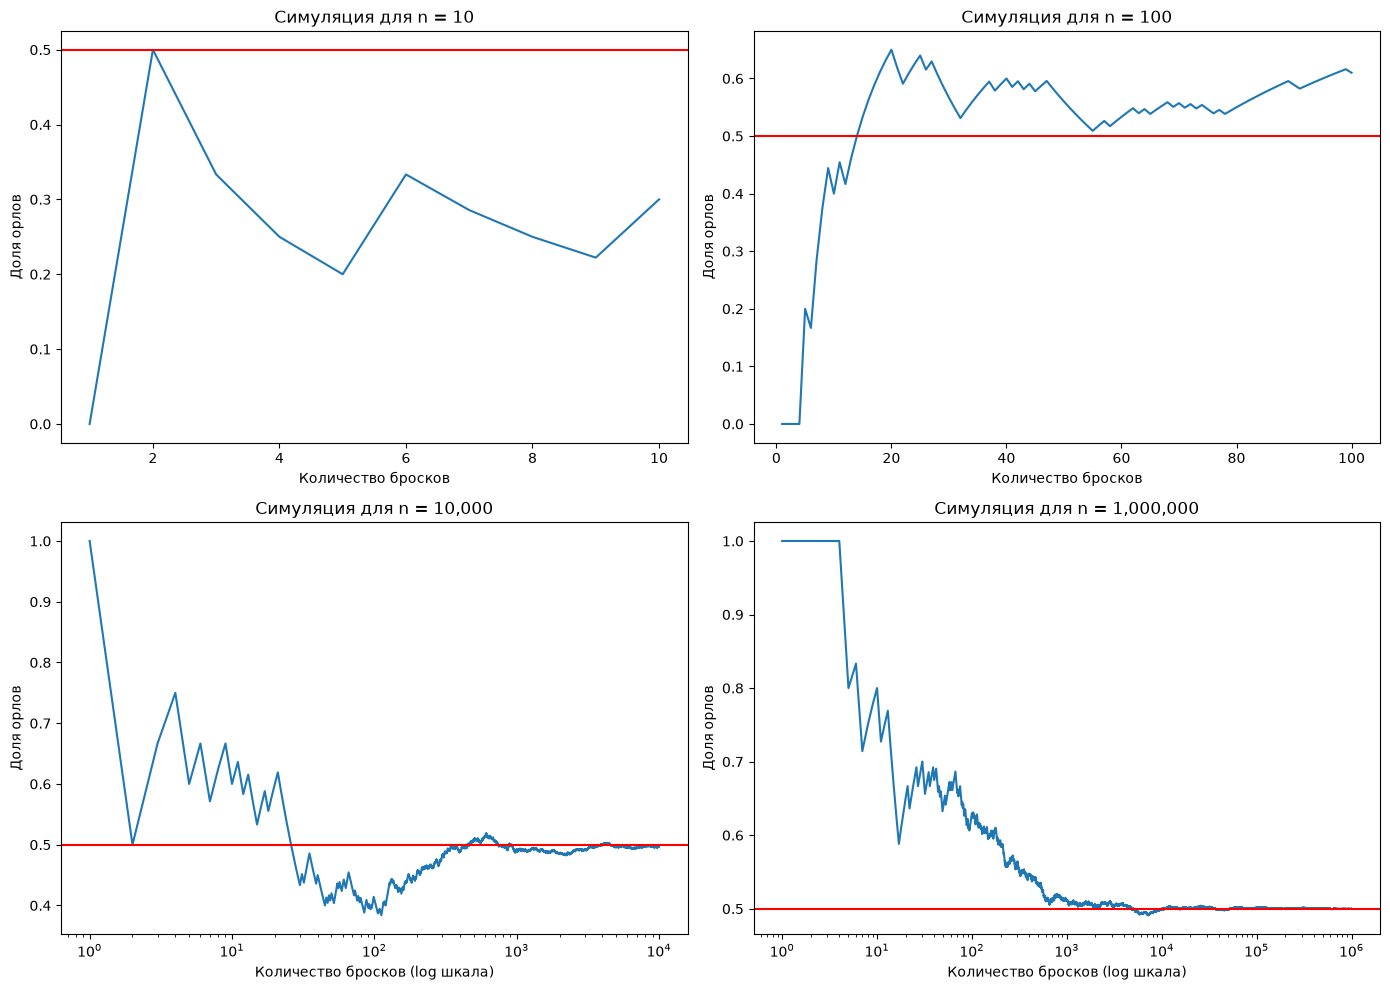

In [6]:
from matplotlib import pyplot as plt


n_val = [10, 100, 10000, 1000000]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

np.random.seed(42)

for i, n in enumerate(n_val):
    # 0 - решка, 1 - орел 
    tosses = np.random.randint(0, 2, size=n)
    cum_sum = np.cumsum(tosses)
    trials = np.arange(1, n + 1)

    proportions = cum_sum / trials

    ax = axes[i]
    ax.plot(trials, proportions)
    ax.axhline(y=0.5, color="red")

    if n >= 10000:
        ax.set_xscale("log")
        ax.set_xlabel('Количество бросков (log шкала)')
    else:
        ax.set_xlabel('Количество бросков')

    ax.set_title(f'Симуляция для n = {n:,}')
    ax.set_ylabel("Доля орлов")
    

plt.tight_layout()
plt.show()

    



Посмотрев на сгенерированные графики, вы наглядно увидите ЗБЧ в действии:
1. При **n = 10** и **n = 100** график сильно штормит. Случайность доминирует, доля орлов может легко улетать к 0.8 или 0.3. Если ваш датасет в ML будет такого размера, модель просто «зазубрит» случайный шум (переобучится).
2. При **n = 10 000** и **n = 1 000 000** график в самом начале колеблется, но затем превращается в идеальную прямую линию, намертво прижатую к значению **0.5**. Случайные отклонения взаимно погасили друг друга.

В машинном обучении это означает, что метрикам качества (например, Accuracy на тестовой выборке) или оценкам вероятностей в наивном Байесе можно доверять только тогда, когда объем данных достаточно велик, чтобы сработал Закон больших чисел.

---
---

### Разбор ключевой логики симуляции (NumPy)

Вся магия и скорость работы симуляции Закона больших чисел скрываются в трех строчках кода, использующих векторные операции библиотеки `NumPy`. Давайте подробно разберем, как они работают «на пальцах» на примере небольшого эксперимента из **\(n = 4\) бросков**.

---

#### Строка 1: Симуляция бросков
```python
tosses = np.random.randint(0, 2, size=n)
```
* **Что делает:** Генерирует массив из случайных целых чисел. 
* **Как работает:** Функция `randint(0, 2)` выбирает случайное число из диапазона от `0` (включительно) до `2` (не включая её). То есть на выходе будут только `0` и `1`.
* **Аналогия для ML:** Мы договариваемся, что **`0` — это решка**, а **`1` — это орел (наш «успех»)**. Параметр `size=n` указывает, сколько раз нужно «бросить монетку».
* **Пример результата (для \(n=4\)):** `[1, 0, 1, 1]` *(выпал орел, затем решка, затем еще два орла)*.

---

#### Строка 2: Накопление результатов (Кумулятивная сумма)
```python
cum_sum = np.cumsum(tosses)
```
* **Что делает:** Считает накопленную сумму элементов массива, двигаясь по нему слева направо шаг за шагом.
* **Как работает:** На каждом шаге к текущей сумме прибавляется новое значение из массива `tosses`. Так как решка — это `0`, она не увеличивает сумму, а орел — это `1`, он увеличивает сумму на единицу. Таким образом, мы получаем историю того, **сколько всего орлов выпало к каждому конкретному моменту времени**.
* **Пример расчета для нашего массива `[1, 0, 1, 1]`:**
  * Шаг 1: `1` *(выпал 1-й орел)* \(\rightarrow\) текущая сумма = **`1`**
  * Шаг 2: `1 + 0` *(выпала решка)* \(\rightarrow\) текущая сумма = **`1`**
  * Шаг 3: `1 + 0 + 1` *(выпал 2-й орел)* \(\rightarrow\) текущая сумма = **`2`**
  * Шаг 4: `1 + 0 + 1 + 1` *(выпал 3-й орел)* \(\rightarrow\) текущая сумма = **`3`**
* **Пример результата:** `[1, 1, 2, 3]`

---

#### Строка 3: Создание счетчика попыток (Знаменатели)
```python
trials = np.arange(1, n + 1)
```
* **What it does:** Создает последовательность чисел от 1 до $n$.
* **Как работает:** Функция `np.arange(start, stop)` генерирует упорядоченный массив, начиная со значения `start` и заканчивая точкой `stop - 1`. Это порядковые номера наших бросков, которые понадобятся в качестве знаменателей.
* **Пример результата (для $n=4$):** `[1, 2, 3, 4]`

---

### Финал: Нахождение текущей доли успехов

В коде эти массивы делятся друг на друга: `current_proportions = cum_sum / trials`. 

Благодаря векторной архитектуре NumPy, деление происходит поэлементно (каждое число из `cum_sum` делится на число, стоящее на той же позиции в `trials`):
* На 1-м броске: $1 / 1 =$ **`1.0`** *(доля орлов 100%)*
* На 2-м броске: $1 / 2 =$ **`0.5`** *(доля орлов 50%)*
* На 3-м броске: $2 / 3 =$ **`0.66`** *(доля орлов 66.6%)*
* На 4-м броске: $3 / 4 =$ **`0.75`** *(доля орлов 75%)*

Полученный массив `[1.0, 0.5, 0.66, 0.75]` — это и есть координаты по оси $Y$, которые график соединяет синей линией, наглядно показывая весь путь сходимости к истинному значению `0.5`.


---
---
5. **E и Var на симуляции.** Сгенерируйте 10 000 чисел из распределения Пуассона с λ=3. Проверьте, что среднее ≈ дисперсия ≈ 3.


# Математический справочник распределений для ML

Каждое вероятностное распределение полностью описывается своей математической функцией (законом распределения для дискретных или плотностью вероятности для непрерывных величин). Ниже приведены строгие формулы и их основные числовые характеристики.

---

## 1. Дискретные распределения

Для дискретных величин закон распределения задает вероятность $P(X = k)$ для каждого конкретного исхода $k$. 

### А. Распределение Бернулли: $X \sim \text{Bernoulli}(p)$
Описывает один эксперимент с вероятностью успеха $p$. Переменная $X$ принимает только значения $1$ (успех) или $0$ (неудача).

* **Формула вероятности:**
$$P(X = k) = p^k (1-p)^{1-k}, \quad \text{где } k \in \{0, 1\}$$

* **Числовые характеристики:**
  * Математическое ожидание: $E[X] = p$
  * Дисперсия: $Var(X) = p(1-p)$

### Б. Биномиальное распределение: $X \sim \text{Bin}(n, p)$
Описывает число успехов $k$ в серии из $n$ независимых испытаний Бернулли.

* **Формула вероятности:**
$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}, \quad \text{где } k \in \{0, 1, \dots, n\}$$
*Где $\binom{n}{k} = \frac{n!}{k!(n-k)!}$ — биномиальный коэффициент (число сочетаний).*

* **Условие нормировки:** $\sum_{k=0}^{n} \binom{n}{k} p^k (1-p)^{n-k} = 1$
* **Числовые характеристики:**
  * Математическое ожидание: $E[X] = np$
  * Дисперсия: $Var(X) = np(1-p)$

### В. Распределение Пуассона: $X \sim \text{Poisson}(\lambda)$
Описывает количество событий за фиксированный интервал времени при средней интенсивности $\lambda$.

* **Формула вероятности:**
$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}, \quad \text{где } k \in \{0, 1, 2, \dots\}, \, \lambda > 0$$

* **Условие нормировки:** $\sum_{k=0}^{\infty} \frac{\lambda^k e^{-\lambda}}{k!} = 1$
* **Числовые характеристики:**
  * Математическое ожидание: $E[X] = \lambda$
  * Дисперсия: $Var(X) = \lambda$ *(уникальное свойство: матожидание равно дисперсии)*

---

## 2. Непрерывные распределения

Для непрерывных величин вероятность точного совпадения равна нулю, поэтому они описываются **функцией плотности вероятности** $f(x)$.

### А. Нормальное распределение (Гаусс): $X \sim \mathcal{N}(\mu, \sigma^2)$
Главное распределение в статистике. Задается матожиданием $\mu$ и среднеквадратическим отклонением $\sigma$.

* **Функция плотности вероятности (PDF):**
$$f(x) = \frac{1}{\sigma \sqrt{2\pi}} \exp\left( -\frac{(x - \mu)^2}{2\sigma^2} \right), \quad \text{где } x \in (-\infty, +\infty)$$

* **Условие нормировки (интеграл Пуассона):** $\int_{-\infty}^{+\infty} \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{(x - \mu)^2}{2\sigma^2}} dx = 1$
* **Числовые характеристики:**
  * Математическое ожидание: $E[X] = \mu$
  * Дисперсия: $Var(X) = \sigma^2$

### Б. Равномерное распределение: $X \sim \mathcal{U}(a, b)$
Все исходы внутри непрерывного интервала $[a, b]$ имеют абсолютно одинаковую плотность вероятности.

* **Функция плотности вероятности (PDF):**
$$f(x) = \begin{cases} \frac{1}{b - a}, & \text{если } a \le x \le b \\ 0, & \text{если } x < a \text{ или } x > b \end{cases}$$

* **Условие нормировки:** $\int_{a}^{b} \frac{1}{b - a} dx = 1$
* **Числовые характеристики:**
  * Математическое ожидание: $E[X] = \frac{a + b}{2}$
  * Дисперсия: $Var(X) = \frac{(b - a)^2}{12}$

### В. Экспоненциальное распределение: $X \sim \text{Exp}(\lambda)$
Описывает время между независимыми случайными событиями, происходящими с постоянной средней интенсивностью $\lambda$.

* **Функция плотности вероятности (PDF):**
$$f(x) = \begin{cases} \lambda e^{-\lambda x}, & \text{если } x \ge 0 \\ 0, & \text{если } x < 0 \end{cases}, \quad \text{где } \lambda > 0$$

* **Условие нормировки:** $\int_{0}^{+\infty} \lambda e^{-\lambda x} dx = 1$
* **Числовые характеристики:**
  * Математическое ожидание: $E[X] = \frac{1}{\lambda}$
  * Дисперсия: $Var(X) = \frac{1}{\lambda^2}$


In [7]:
# np.random.seed(42)
n = 10000
lambda_val = 3

X = np.random.poisson(lam=lambda_val, size=n)
print(f"Математическое ожидание равно E(X) = {X.mean()}")
print(f"Дисперсия равна D(X) = Var(X) = {X.var()}")


Математическое ожидание равно E(X) = 3.0166
Дисперсия равна D(X) = Var(X) = 3.0183244399999998


---
6. **Ковариационная матрица.** Сгенерируйте 1000 точек из 2D-нормального распределения с заданной ковариацией. Восстановите ковариационную матрицу из выборки. Должна совпасть с заданной.


In [8]:
np.random.seed(42)

n = 1000
true_mean = [175, 70]
true_cov = [[1.0, 0.8], 
            [0.8, 1.0]]

points = np.random.multivariate_normal(mean=true_mean, cov=true_cov, size=n)
X_points = points[:, 0]
Y_points = points[:, 1]

pred_cov = np.cov(X_points, Y_points)
pred_cov_2 = np.cov(points, rowvar=False)

print(pred_cov)
print(pred_cov_2)


[[0.93674039 0.72919866]
 [0.72919866 0.93371387]]
[[0.93674039 0.72919866]
 [0.72919866 0.93371387]]


---
7. **Наивный байес руками.** Постройте классификатор спама на 5 простых текстах. Используйте мешок слов и формулу Байеса с предположением независимости.


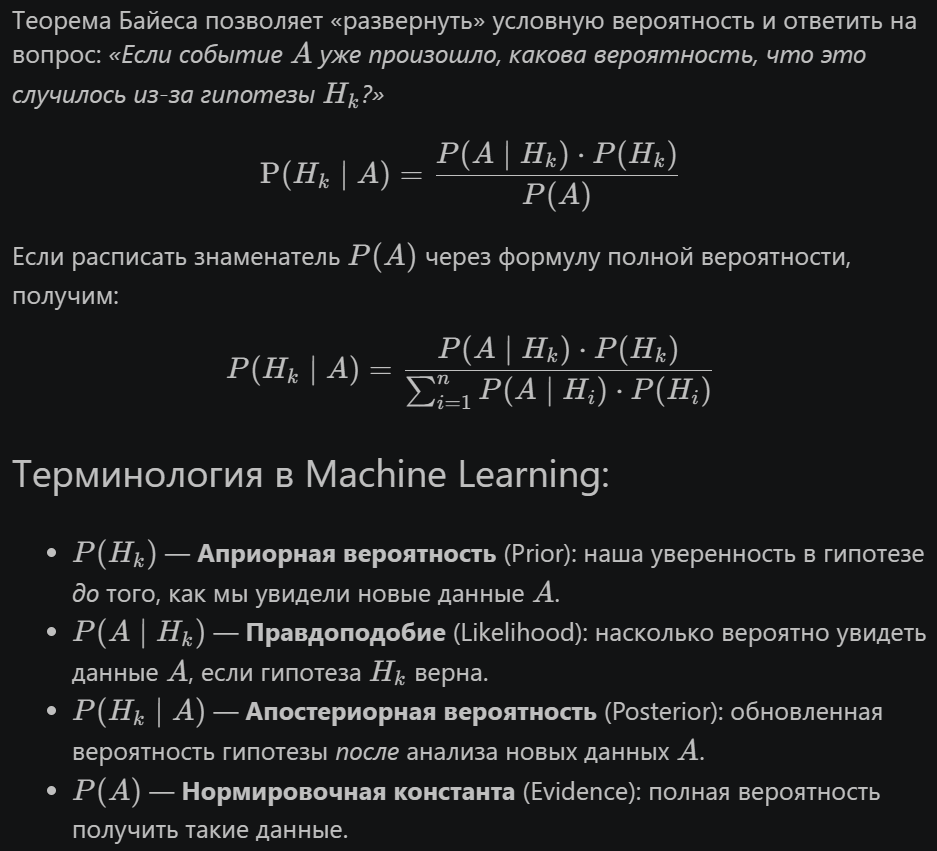

### Главный ментальный сдвиг: Разница между направлениями вероятностей

Понимание Наивного Байеса и вероятностного машинного обучения держится на четком разделении двух условных вероятностей, которые на первый взгляд кажутся похожими, но смотрят в совершенно разные стороны.

---

## 1. Правдоподобие (Взгляд из прошлого) — $P(\text{Фраза} \mid \text{Спамер})$

* **Человеческий смысл:** Какова вероятность того, что слова из этой фразы будут использованы спамером, если мы *точно знаем*, что записку написал спамер?
* **Роль в ML:** Это статистика. Мы открываем уже готовый «мешок слов» Спамера и считаем частоту слов. Это то, что модель **извлекает из обучающих данных**.

---

## 2. Апостериорная вероятность (Прогноз на будущее) — $P(\text{Спамер} \mid \text{Фраза})$

* **Человеческий смысл:** Какова вероятность того, что перед нами спам, если к нам *только что пришла* конкретная фраза?
* **Роль в ML:** Это предсказание. Текст записки нам уже известен (это факт), а вот автор скрыт. Это то, что модель **прогнозирует на практике** для новых писем.

---

## Итог: Мост Байеса

В реальной жизни нам всегда нужно знать **$P(\text{Спамер} \mid \text{Фраза})$**, чтобы заблокировать спам. Но посчитать её напрямую из текста невозможно. 

**Теорема Байеса — это математический мост.** Она берет то, что легко посчитать по готовой исторической статистике ($P(\text{Фраза} \mid \text{Спамер})$), и превращает в то, что нам жизненно необходимо спрогнозировать в реальности ($P(\text{Спамер} \mid \text{Фраза})$).


In [9]:
from collections import Counter
import math


texts = [
    "купи кредит скидка сейчас",         # Спам (1)
    "акция кредит выиграй миллион",      # Спам (1)
    "скидка на куртки только сегодня",   # Спам (1)
    "привет как дела зайди в гости",     # Не спам (0)
    "пришли мне отчет по работе"         # Не спам (0)
]
labels = [1, 1, 1, 0, 0]  # 1 - спам, 0 - не спам

# Bag of words
spam_words = []
ham_words =[]
all_words = set()

# Разносим слова по мешкам в зависимости от класса
for text, label in zip(texts, labels):
    words = text.split()
    all_words.update(words)

    if label == 1:
        spam_words.extend(words)
    else:
        ham_words.extend(words)

# Считаем, сколько раз каждое слово встретилось в каждом классе
spam_counts = Counter(spam_words)
ham_counts = Counter(ham_words)

# Общее количество слов в каждом мешке
total_spam_words = len(spam_words)
total_ham_words = len(ham_words)

# Размер уникального словаря (нужен для сглаживания Лапласа)
vocab_size = len(all_words)

# Априорные вероятности классов P(Spam) и P(Ham)
P_spam_prior = labels.count(1) / len(labels)
P_ham_prior = labels.count(0) / len(labels)


def predict_spam(new_text):
    new_words = new_text.lower().split()

    # Стартуем с априорных вероятностей.
    # Используем логарифмы, так как перемножение 
    # большого количества маленьких вероятностей
    # может привести к занулению числа в памяти компьютера (underflow).
    log_p_spam = math.log(P_spam_prior)
    log_p_ham = math.log(P_ham_prior)

    for word in new_words:
        # Сглаживание Лапласа: прибавляем +1 к счетчику слова в числителе, 
        # и размер словаря (vocab_size) к общему числу слов в знаменателе.
        # Это защищает от умножения на 0, если слова нет в обучающей выборке.
        p_word_given_spam = (spam_counts[word] + 1) / (total_spam_words + vocab_size)
        log_p_spam += math.log(p_word_given_spam)

        p_word_given_ham = (ham_counts[word] + 1) / (total_ham_words + vocab_size)
        log_p_ham += math.log(p_word_given_ham)

    chance_spam = math.exp(log_p_spam)
    chance_ham = math.exp(log_p_ham)

    # Нормализуем числитель, чтобы сумма вероятностей была равна 1
    total_chance = chance_spam + chance_ham
    p_spam = chance_spam / total_chance
    p_ham = chance_ham / total_chance

    # так как знаменатель был бы одинаковым, сравниваем только числители
    if p_spam > p_ham:
        return "Спам"
    else:
        return "Не спам"

print(predict_spam("Привет кредит скидка"))
print(predict_spam("Пришли мне отчет про велосипед"))

Спам
Не спам


# Наивный Байесовский Классификатор (Naive Bayes Classifier)

**Наивный Байес** — это классический вероятностный алгоритм машинного обучения, основанный на применении теоремы Байеса со строгим (и «наивным») предположением о том, что все признаки (слова в тексте) являются независимыми друг от друга.

---

## 1. Математическая формулировка задачи

Пусть у нас есть текст (документ), состоящий из набора слов $D = (w_1, w_2, \dots, w_m)$, и мы хотим определить его класс $C$ (например, $C_1 = \text{Spam}$, $C_0 = \text{Ham}$).

Согласно теореме Байеса, апостериорная вероятность того, что документ $D$ принадлежит классу $C$, равна:

$$P(C \mid w_1, w_2, \dots, w_m) = \frac{P(w_1, w_2, \dots, w_m \mid C) \cdot P(C)}{P(w_1, w_2, \dots, w_m)}$$

### Гипотеза наивной независимости:
Поскольку знаменатель $P(w_1, \dots, w_m)$ одинаков для всех классов, мы можем его игнорировать при максимизации. Главная «наивность» алгоритма заключается в предположении, что слова появляются в тексте независимо друг от друга при заданном классе $C$:

$$P(w_1, w_2, \dots, w_m \mid C) = P(w_1 \mid C) \cdot P(w_2 \mid C) \dots P(w_m \mid C) = \prod_{j=1}^{m} P(w_j \mid C)$$

Итоговая рабочая формула классификатора:
$$C_{predicted} = \arg\max_{C} \left[ P(C) \cdot \prod_{j=1}^{m} P(w_j \mid C) \right]$$

---

## 2. Сглаживание Лапласа (Laplace Smoothing)

**Проблема нулевой вероятности:** Если в классифицируемом тексте встретится хотя бы одно слово $w_{new}$, которого не было в обучающей выборке для класса $C$, то условная частотная вероятность $P(w_{new} \mid C)$ будет равна $0$. Из-за операции произведения ($\prod$) вся цепочка вероятностей мгновенно занулится: $P(C) \cdot \dots \cdot 0 \cdot \dots = 0$.

Чтобы этого избежать, применяется **сглаживание Лапласа (аддитивное сглаживание)**. К счетчику каждого слова в числителе искусственно прибавляется единица, а к общему числу слов в знаменателе — размер уникального словаря:

$$P(w_j \mid C) = \frac{N_{jc} + 1}{N_c + |V|}$$

* $N_{jc}$ — сколько раз слово $w_j$ встретилось в документах класса $C$.
* $N_c$ — суммарное количество всех слов в документах класса $C$.
* $|V|$ — размер всего уникального словаря (количество уникальных слов во всей обучающей выборке).

---

## 3. Логарифмический трюк (Log-Sum-Exp Trick)

В реальных задачах тексты содержат сотни и тысячи слов. Вероятность встретить отдельное слово мала ($P(w_j \mid C) \ll 1$). Если перемножить сотни чисел вида $0.01$, в памяти компьютера получится экстремально маленькое число с огромным количеством нулей после запятой, что приведет к ошибке **арифметического недоедания (underflow)** — компьютер просто округлит результат до $0$.

**Решение:** Перевести произведение в сумму с помощью логарифмирования. Так как логарифм — монотонно возрастающая функция, операция поиска максимума ($\arg\max$) не изменит своего результата:

$$\log \left( P(C) \cdot \prod_{j=1}^{m} P(w_j \mid C) \right) = \log P(C) + \sum_{j=1}^{m} \log P(w_j \mid C)$$

Благодаря этому трюку умножение мелких долей заменяется на обычное сложение отрицательных чисел, что делает вычисления стабильными.

---

## 4. Алгоритм работы «Мешка слов» (Bag of Words)

1. **Обучение (Fit):**
   * Посчитать априорные вероятности классов: $P(C) = \frac{\text{Кол-во документов класса } C}{\text{Всего документов}}$.
   * Собрать уникальный словарь всех слов $|V|$.
   * Для каждого класса создать счетчик слов («мешок») и посчитать общую сумму слов $N_c$.
2. **Предсказание (Predict):**
   * Разбить новый текст на токены (слова).
   * Для каждого класса рассчитать сумму логарифмов априорной вероятности и условных вероятностей слов со сглаживанием Лапласа.
   * Сравнить полученные суммы и выбрать класс с наибольшим значением.


---
# Наивный Байес «на пальцах»: Разбор на детективной аналогии

Если формулы кажутся абстрактными, давайте разберем, как формула Байеса работает внутри текстового классификатора, на простом жизненном примере. Представьте, что мы — детективы, которые разбирают архив записок.

---

## 1. Наш детективный архив (Обучающая выборка)

У нас есть папка с 5 записками от двух подозреваемых: **Спамера** и вашего **Друга**.
* **Записки от Спамера:**
  1. *«купи кредит»*
  2. *«акция кредит»*
  3. *«купи акция»*
* **Записки от Друга:**
  4. *«привет как»*
  5. *«привет друг»*

В терминах машинного обучения 5 записок — это **датасет**, а авторы — это **классы** (1 — Спам, 0 — Не-спам).

---

## 2. Поиск формулы Байеса в детективном расследовании

К нам в агентство приносит новую закрытую записку с текстом: **«Привет купи»**. Наша задача — узнать, кто её автор.

Классическая формула Байеса выглядит так:
$$P(\text{Причина} \mid \text{Следствие}) = \frac{P(\text{Следствие} \mid \text{Причина}) \cdot P(\text{Причина})}{P(\text{Следствие})}$$

В нашей задаче:
* **Причина** — это класс автора (`Спамер` или `Друг`).
* **Следствие** — это полученный текст (`«Привет купи»`).

Мы хотим сравнить, какая вероятность выше: $P(\text{Спамер} \mid \text{«Привет купи»})$ или $P(\text{Друг} \mid \text{«Привет купи»})$.

---

## 3. Расчет числителя формулы Байеса для каждого класса

Поскольку нижняя часть формулы (знаменатель $P(\text{«Привет купи»})$) абсолютно одинакова для обоих подозреваемых, она не влияет на то, какое число окажется больше. Мы можем её проигнорировать и считать **только числитель**: $\text{Балл} = P(\text{Текст} \mid \text{Класс}) \cdot P(\text{Класс})$.

### Шаг А: Расчет априорной вероятности $P(\text{Класс})$
Это наши стартовые подозрения до того, как мы прочитали текст, основанные только на размерах архива (всего 5 записок):
* Стартовый шанс Спамера: $P(\text{Спамер}) = 3 / 5 = \mathbf{0.6}$ (60% папки)
* Стартовый шанс Друга: $P(\text{Друг}) = 2 / 5 = \mathbf{0.4}$ (40% папки)

### Шаг Б: Расчет правдоподобия $P(\text{Текст} \mid \text{Класс})$ через «Мешки слов»
Чтобы узнать, с какой вероятностью Спамер или Друг могли написать фразу *«Привет купи»*, мы применяем **«наивное» предположение независимости** и раскладываем фразу на произведение отдельных слов:
$$P(\text{«Привет купи»} \mid \text{Класс}) = P(\text{«Привет»} \mid \text{Класс}) \cdot P(\text{«купи»} \mid \text{Класс})$$

Вытряхнем слова из записок в два «мешка»:
* **В мешке Спамера 6 слов:** *купи* (2), *кредит* (2), *акция* (2). Слова *«привет»* там **0**.
* **В мешке Друга 4 слова:** *привет* (2), *как* (1), *друг* (1). Слова *«купи»* там **0**.

#### Проблема нуля и Сглаживание Лапласа
Если мы просто умножим вероятности, то Спамер получит $0$ за слово *«привет»*, а Друг — $0$ за слово *«купи»*. Всё обнулится. 
Чтобы спасти математику, мы применяем **сглаживание Лапласа**: мысленно добавляем **+1** к счетчику каждого слова, а знаменатель (общую кучу слов) расширяем на размер всего уникального словаря (у нас это 6 уникальных слов: *купи, кредит, акция, привет, как, друг*).

* **Пересчитываем мешок Спамера (было 6 слов, со сглаживанием стало $6 + 6 = 12$):**
  * Шанс слова *«Привет»*: было 0, стало 1. Вероятность = $\frac{1}{12}$
  * Шанс слова *«Купи»*: было 2, стало 3. Вероятность = $\frac{3}{12}$
* **Пересчитываем мешок Друга (было 4 слова, со сглаживанием стало $4 + 6 = 10$):**
  * Шанс слова *«Привет»*: было 2, стало 3. Вероятность = $\frac{3}{10}$
  * Шанс слова *«Купи»*: было 0, стало 1. Вероятность = $\frac{1}{10}$

---

## 4. Финальный вердикт (Сравнение числителей)

Теперь собираем числитель формулы Байеса целиком (перемножаем стартовый шанс класса на шансы слов):

* **Итоговый балл Спамера:**
$$\text{Балл} = P(\text{Спамер}) \cdot P(\text{«Привет»} \mid \text{Спамер}) \cdot P(\text{«купи»} \mid \text{Спамер}) = 0.6 \cdot \frac{1}{12} \cdot \frac{3}{12} = \mathbf{0.0125}$$

* **Итоговый балл Друга:**
$$\text{Балл} = P(\text{Друг}) \cdot P(\text{«Привет»} \mid \text{Друг}) \cdot P(\text{«купи»} \mid \text{Друг}) = 0.4 \cdot \frac{3}{10} \cdot \frac{1}{10} = \mathbf{0.0120}$$

**Вердикт:** Балл Спамера ($0.0125$) оказался чуть выше, чем балл Друга ($0.0120$). Модель классифицирует записку как **СПАМ**. 

*Почему так, ведь слово «Привет» дружеское?* Потому что сильный стартовый перекос в архиве в сторону спама ($0.6$ против $0.4$) перевесил чашу весов. В коде на Python этот процесс абсолютно идентичен, только умножение заменено на сложение логарифмов для защиты компьютера от слишком мелких дробей.


---
---
8. **Условные вероятности на датасете.** Возьмите Titanic. Посчитайте `P(выжил | женщина)`, `P(выжил | мужчина)`, `P(выжил | 1 класс)`. Какая фича сильнее всего влияет?


In [37]:
import seaborn as sns
# import pandas as pd


df = sns.load_dataset("titanic")
# print(pd.DataFrame(df).head(5))

women = df[df["sex"] == "female"]
p_survived_given_female = len(women[women["survived"] == True]) / len(women)
print(women["survived"].mean())
print(p_survived_given_female,'\n')

man = df[df["sex"] == "male"]
p_survived_given_male = len(man[man["survived"] == True]) / len(man)
print(man["survived"].mean())
print(p_survived_given_male,'\n')

first_class = df[df["class"] == "First"]
p_survived_given_first_class = len(first_class[first_class["survived"] == True]) / len(first_class)
print(first_class["survived"].mean())
print(p_survived_given_first_class,'\n')

base_survival_rate = df['survived'].mean()
print(base_survival_rate,'\n')

print("Сильнее всего на выживаемость влияет пол пассажира (фича 'sex').")

0.7420382165605095
0.7420382165605095 

0.18890814558058924
0.18890814558058924 

0.6296296296296297
0.6296296296296297 

0.3838383838383838 

Сильнее всего на выживаемость влияет пол пассажира (фича 'sex').


---
---

# Анализ условных вероятностей на датасете Titanic

Практический расчет условных вероятностей на реальных данных пассажиров Титаника наглядно иллюстрирует, как скрытые признаки (фичи) влияют на целевую переменную (выживаемость).

---

## 1. Базовые показатели выборки
* **Общая вероятность выжить $P(\text{выжил})$:** $\approx 38.38\%$
Это среднее значение по всей колонке `survived`. Если выбрать случайного человека с корабля, не зная о нем ничего, шанс его спасения составлял около 38%.

---

## 2. Ловушка интерпретации: Условная вероятность vs Доля от общего

При анализе результатов важно правильно переводить математические условные вероятности на человеческий язык.

### Правильное чтение результатов:
* **$P(\text{выжил} \mid \text{женщина}) \approx 74.20\%$**
  * *Правильно:* «Если пассажир — женщина, то вероятность её выживания составляет 74.2%». (Пол, как условие, сужает наш выбор только до женщин, и 74.2% из них спаслись).

* **$P(\text{выжил} \mid \text{мужчина}) \approx 18.89\%$**
  * *Правильно:* «Среди всех мужчин на борту выжило только 18.9%». 

* **$P(\text{выжил} \mid \text{1 класс}) \approx 62.96\%$**
  * *Правильно:* «Пассажир первого класса имел шанс спастись 63%».

---

## 3. Вывод для Machine Learning

Этот эксперимент показывает концепцию **информативности признаков** (Feature Importance):
1. Фича `sex` (пол) обладает огромной предсказательной силой. Вероятность выживания колеблется от **19%** для мужчин до **74%** для женщин. Разброс колоссальный. Любая ML-модель (например, Дерево решений) в первую очередь будет разделять данные именно по этому признаку.
2. Фича `class` (класс каюты) также информативна: шанс выжить в 1 классе (**63%**) существенно выше базового среднего значения по кораблю (**38%**).
